In [1]:
!pip install tensorflow

In [3]:
import tensorflow
print(tensorflow.__version__)

2.21.0


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 314ms/step - accuracy: 0.1574 - loss: 2.2543 - val_accuracy: 0.1250 - val_loss: 2.0793 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.2723 - loss: 2.0753 - val_accuracy: 0.0833 - val_loss: 2.0791 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - accuracy: 0.1429 - loss: 2.0746 - val_accuracy: 0.1250 - val_loss: 2.0792 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.1239 - loss: 2.0746 - val_accuracy: 0.1250 - val_loss: 2.0783 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.1641 - loss: 2.0786 - val_accuracy: 0.2083 - val_loss: 2.0772 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.1808 - loss: 2.0471 - val_accuracy: 0.0833 - val_loss: 2.0771 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.1652 - loss: 2.0492 -

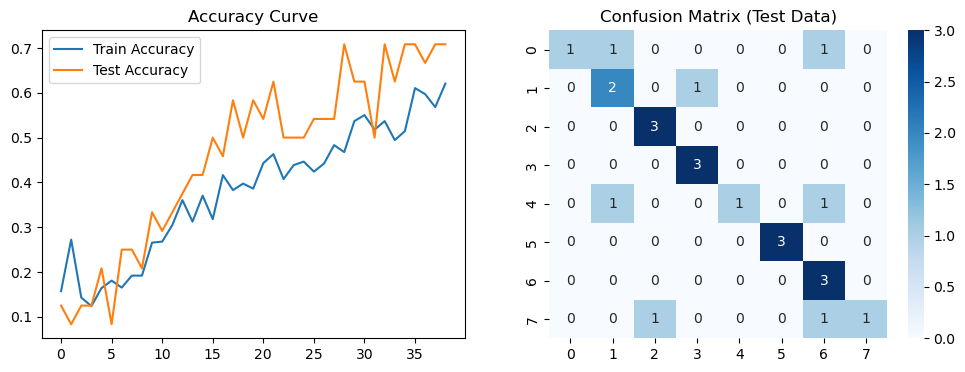

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7083 - loss: 0.8982

最終測試資料正確率: 70.83%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. 資料讀取與預處理 [cite: 9]
df = pd.read_csv(r"C:\cnn_project\CK+ Dataset.csv") # 請確認路徑正確

def parse_pixels(pixel_str):
    return np.array(pixel_str.split(), dtype='float32').reshape(48, 48, 1)

df['pixel_matrix'] = df['pixels'].apply(parse_pixels)

# 2. 嚴格遵守切割規則：每類最後 3 張為測試 
train_data, test_data = [], []
train_labels, test_labels = [], []

for emotion_id in range(8):
    emotion_df = df[df['emotion'] == emotion_id]
    test_subset = emotion_df.tail(3)
    train_subset = emotion_df.iloc[:-3]
    
    test_data.extend(test_subset['pixel_matrix'].values)
    test_labels.extend(test_subset['emotion'].values)
    train_data.extend(train_subset['pixel_matrix'].values)
    train_labels.extend(train_subset['emotion'].values)

# 歸一化 (Normalize) [cite: 9]
X_train = np.array(train_data) / 255.0
X_test = np.array(test_data) / 255.0
y_train = np.array(train_labels)
y_test = np.array(test_labels)
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

# 3. 建立 CNN 模型 (符合：Conv → ReLU → Pooling → FC → Softmax) 
model = models.Sequential([

    layers.Input(shape=(48,48,1)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(128, (3,3),
                  padding='same',
                  activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(256, (3,3),
                  padding='same',
                  activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    # 增強防 overfitting
    layers.Dropout(0.6),

    layers.Dense(8, activation='softmax')
])

# 設定損失函數：Cross Entropy [cite: 12, 20]
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. 訓練優化策略 (Augmentation & Callbacks) 
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# 自動止損與降低學習率
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.2, patience=5)

# 5. 開始訓練 [cite: 21]
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# 6. 產出報告所需的評估結果 
# 學習曲線 [cite: 22]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# 混淆矩陣 (Confusion Matrix) 
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

# 顯示最終測試正確率 [cite: 25]
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n最終測試資料正確率: {test_acc*100:.2f}%")